# AI Generated Audio Detection Walkthrough

#### Framing the Problem

Preserving authenticity in art is a cause worth researching for. As generative music systems rapidly improve, being able to distinguish between human created and AI-generated content is becoming increasingly difficult. It's important to protect artist rights against copyright infringement and support authenticity in music, which is part of the mission that inspired this project. The goal of building a model that will detect whether a song is AI generated or not is to promote transparency and awareness in the listening experience. 
For platforms like Spotify that distribute music, this presents both a product and policy challenge: how can we provide transparency to users while preserving fairness for artists?

The core risk is distribution shift. Detection models often perform well on the specific generators they were trained on, but fail when confronted with audio from a new model. In practice, this means a detection system may appear highly accurate in evaluation, yet break down when deployed against unseen generation tools.

This project investigates that failure mode directly: how well does a detection model generalize to unseen generators, and can lightweight fine tuning improve robustness?

#### Translating Original Capstone into Reproducible Demonstration

This work builds on a year long capstone sponsored by Sound Ethics, a music technology startup focused on AI transparency. In the original project, we identified generalization as the primary weakness of existing detection systems. Many models were trained on a select few generators (like Suno and Udio), and while performance was strong in distribution, recall collapsed on unseen generators.

To address this, we fine tuned the SpecTTTra model introduced in the SONICS paper using a broader and more representative set of generated audio. That training was conducted on a GPU-enabled VM using a large dataset, so for this reproducible version, I built a simplified, fully reproducible version of the pipeline using randomly sampled subsets and a lightweight baseline model to demonstrate the same core evaluation framework. This will reflect the same process and evaluations that we went through to get to our final result - improving the accuracy of detection models from 18.4% to 86.8%.


This is the simplified but structurally equal pipeline I follow for this reproducible demonstration:
- Train a baseline CNN on 150 fake SONICS tracks and 150 real tracks from the Free Music Archive
- Evaluate performance under generator shift
- Fine tune on five external generators
- Hold out two generators entirely to measure true generalization

#### Dataset Construction

To keep this repository fully reproducible, I train and evaluate on a small, balanced dataset built from publicly accessible sources. The fake audio comes from the SONICS dataset of generated tracks, and real audio comes from the Free Music Archive (Creative Commons music). Each track is converted into a 5 second mel spectrogram and saved as a `.npy` file so that training and evaluation run quickly and deterministically.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

repo = Path("..").resolve()

main_manifest = repo / "data" / "interim" / "manifest_processed.csv"
df_main = pd.read_csv(main_manifest)

df_main.drop(columns=["feature_path"]).head(), df_main["label"].value_counts(), df_main["source"].value_counts()

(   label       source
 0      0     fma_real
 1      0     fma_real
 2      0     fma_real
 3      1  sonics_fake
 4      0     fma_real,
 label
 0    150
 1    150
 Name: count, dtype: int64,
 source
 fma_real       150
 sonics_fake    150
 Name: count, dtype: int64)

In [3]:
# Confirm spectrogram shape
x0 = np.load(df_main["feature_path"].iloc[0])
x0.shape, x0.dtype, (x0.min(), x0.max())

((128, 216), dtype('float32'), (np.float32(-2.17759), np.float32(2.972106)))

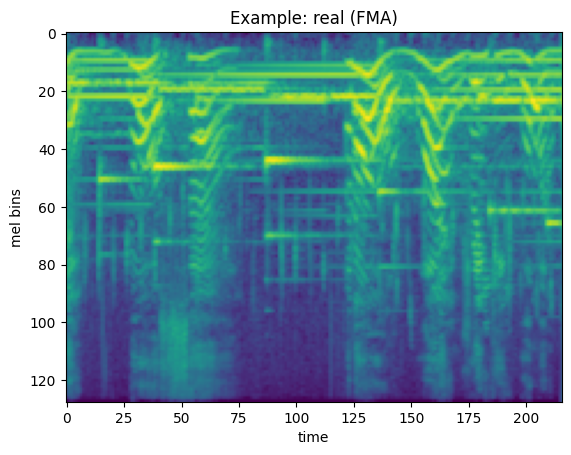

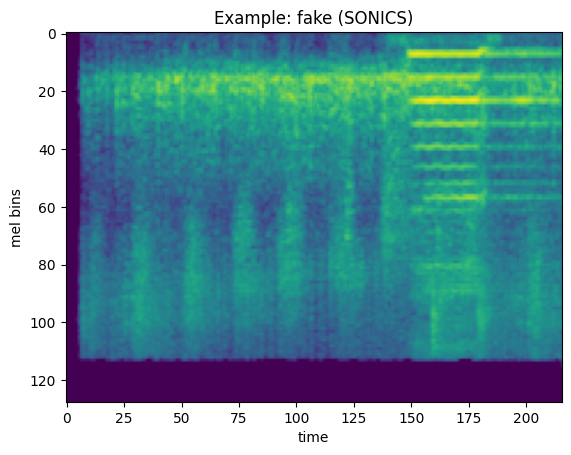

In [16]:
# visualize spectrograms
import matplotlib.pyplot as plt

def show_spec(path, title):
    x = np.load(path)
    plt.figure()
    plt.imshow(x, aspect="auto")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("mel bins")
    plt.show()

show_spec(df_main[df_main["label"]==0]["feature_path"].iloc[0], "Example: real (FMA)")
show_spec(df_main[df_main["label"]==1]["feature_path"].iloc[0], "Example: fake (SONICS)")

#### Baseline Model

First, I used a lightweight CNN as a baseline classifier. The goal is not to replicate the full SONICS architecture, but to build a simplified, readable pipeline and validate the evaluation framework. On a validation split sampled from the same sources as training, the baseline achieves strong performance.

In [5]:
# load baseline metrics
import json

baseline_metrics = json.loads((repo / "results" / "eval_metrics_baseline.json").read_text(encoding="utf-8"))
baseline_metrics["accuracy"], baseline_metrics["average_precision"]

(0.9333333333333333, 0.9868902017579197)

The baseline model performs strongly with in-distribution validation, achieving ~93% accuracy, indicating that it has successfully learned discriminative patterns within the training distribution.

In [6]:
# show threshold table
pd.DataFrame(baseline_metrics["threshold_policies"])

,policy,threshold,precision,recall
0,default_0.50,0.499768,0.906250,0.966667
1,precision_ge_0.90,0.499768,0.906250,0.966667
2,precision_ge_0.95,0.622207,0.962963,0.866667
3,precision_ge_0.99,0.700496,1.000000,0.800000
4,recall_ge_0.95,0.509871,0.935484,0.966667


Different operating thresholds meaningfully shift the precision–recall balance, illustrating how the same model can be tuned for stricter false-positive control or broader detection coverage depending on deployment risk tolerance.

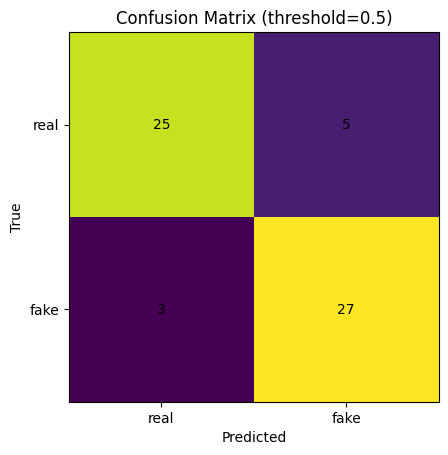

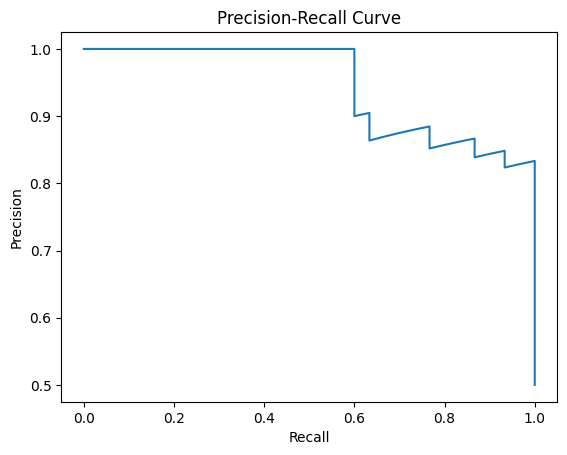

In [7]:
# show baseline plots
from PIL import Image
from IPython.display import display

figs = repo / "results" / "figures"

display(Image.open(figs / "confusion_matrix.png"))
display(Image.open(figs / "precision_recall_curve.png"))

The confusion matrix shows balanced performance across real and fake classes, with relatively few false positives and false negatives under the default threshold. Adding on to that, the precision–recall curve demonstrates strong separability between classes, with high precision maintained across a wide range of recall values.

Taken together, these results confirm strong in-distribution performance while providing flexibility in how the model can be operated depending on risk tolerance.

#### Generalization Test on Unseen Generators

High validation accuracy does not necessarily mean that it's robust to new, unseen generators. To test the model in a deployment-like setting, I evaluated the baseline model on seven entirely unseen generators (Beatoven, Boomy, JenMusic, Mubert, Mureka, Soundverse, and Tad.ai), with 10 tracks from each generator. This isolates a realistic failure mode: the model may learn source specific artifacts rather than generator agnostic signals.

In [8]:
# load external baseline, all generators
ext_baseline_all = pd.read_csv(repo / "results" / "external_baseline_all.csv")
ext_baseline_all

,source,n,recall@0.500,recall@0.622,recall@0.700
0,external_beatoven,10,0.0,0.0,0.0
1,external_boomy,10,0.0,0.0,0.0
2,external_jenmusic,10,0.2,0.2,0.2
3,external_mubert,10,0.0,0.0,0.0
4,external_mureka,10,0.0,0.0,0.0
5,external_soundverse,10,0.0,0.0,0.0
6,external_tad_ai,10,0.0,0.0,0.0


In [9]:
# sort by recall -- threshold 0.5/0.7
ext_baseline_all.sort_values("recall@0.700", ascending=True)

,source,n,recall@0.500,recall@0.622,recall@0.700
0,external_beatoven,10,0.0,0.0,0.0
1,external_boomy,10,0.0,0.0,0.0
3,external_mubert,10,0.0,0.0,0.0
4,external_mureka,10,0.0,0.0,0.0
6,external_tad_ai,10,0.0,0.0,0.0
5,external_soundverse,10,0.0,0.0,0.0
2,external_jenmusic,10,0.2,0.2,0.2


Despite strong in-distribution performance, recall collapses to near zero on most unseen generators, indicating that the model has learned generator specific artifacts rather than generalizable signals of AI synthesis.

#### Fine Tuning with Generator Holdout

To improve the robustness of the detector, I fine tuned the baseline model using 5 generators (50 tracks total) while holding out 2 generators entirely (Mureka and Tad.ai - 20 tracks). This is a generator level holdout: the evaluation set contains generators the model did not see during fine tuning, which better approximates real world rollout conditions.

In [12]:
# before vs. after holdout tables
ext_baseline_holdout = pd.read_csv(repo / "results" / "external_baseline_holdout.csv")
ext_finetuned_holdout = pd.read_csv(repo / "results" / "external_finetuned_holdout.csv")

# join for clean comparison
compare = ext_baseline_holdout.merge(
    ext_finetuned_holdout,
    on=["source","n"],
    suffixes=("_baseline", "_finetuned")
)
compare

,source,n,recall@0.500_baseline,recall@0.622_baseline,recall@0.700_baseline,recall@0.500_finetuned,recall@0.622_finetuned,recall@0.700_finetuned
0,external_mureka,10,0.0,0.0,0.0,1.0,1.0,1.0
1,external_tad_ai,10,0.0,0.0,0.0,1.0,1.0,1.0


Fine tuning on a small set of external generators dramatically improves recall on entirely held out generators, demonstrating that the model can adapt to broader generator diversity.

In [13]:
# show key numbers
cols = [
    "source",
    "recall@0.500_baseline", "recall@0.500_finetuned",
    "recall@0.700_baseline", "recall@0.700_finetuned",
]
compare[cols]

,source,recall@0.500_baseline,recall@0.500_finetuned,recall@0.700_baseline,recall@0.700_finetuned
0,external_mureka,0.0,1.0,0.0,1.0
1,external_tad_ai,0.0,1.0,0.0,1.0


While the held out sample size is small, the improvement from 0% to 100% recall suggests that targeted fine tuning meaningfully increases robustness to generator shift. Still because the generator-level holdout set is small (20 tracks), I interpret these results as directional evidence of improved robustness rather than a definitive estimate of real world performance.

#### Evaluate Tradeoffs

Fine tuning greatly improves recall on unseen generators, but it also shifts the decision boundary and can reduce performance on the original validation distribution. In a product setting, the appropriate operating threshold depends on the relative cost of false positives (incorrectly flagging authentic content) versus false negatives (missing AI-generated content). Below I compare in-distribution performance before/after fine tuning and use threshold policies to illustrate how the same model can be operated differently depending on risk tolerance.

In [14]:
# compare fine tuned vs. baseline
finetuned_metrics = json.loads((repo / "results" / "eval_metrics_finetuned.json").read_text(encoding="utf-8"))

summary = pd.DataFrame([
    {"model": "baseline", "accuracy": baseline_metrics["accuracy"], "avg_precision": baseline_metrics["average_precision"]},
    {"model": "finetuned", "accuracy": finetuned_metrics["accuracy"], "avg_precision": finetuned_metrics["average_precision"]},
])
summary

,model,accuracy,avg_precision
0,baseline,0.933333,0.986890
1,finetuned,0.866667,0.945132


In [15]:
# compare threshold policies
pol_base = pd.DataFrame(baseline_metrics["threshold_policies"])
pol_fine = pd.DataFrame(finetuned_metrics["threshold_policies"])

pol_base["model"] = "baseline"
pol_fine["model"] = "finetuned"

pd.concat([pol_base, pol_fine], ignore_index=True)

,policy,threshold,precision,recall,model
0,default_0.50,0.499768,0.906250,0.966667,baseline
1,precision_ge_0.90,0.499768,0.906250,0.966667,baseline
2,precision_ge_0.95,0.622207,0.962963,0.866667,baseline
3,precision_ge_0.99,0.700496,1.000000,0.800000,baseline
4,recall_ge_0.95,0.509871,0.935484,0.966667,baseline
5,default_0.50,0.440507,0.843750,0.900000,finetuned
6,precision_ge_0.90,0.788551,0.904762,0.633333,finetuned
7,precision_ge_0.95,0.843602,1.000000,0.600000,finetuned
8,precision_ge_0.99,0.843602,1.000000,0.600000,finetuned
9,recall_ge_0.95,0.286450,0.833333,1.000000,finetuned


Different operating thresholds meaningfully shift the precision-recall balance, highlighting how the same model can be tuned for either stricter false positive control or broader detection coverage depending on product risk tolerance.

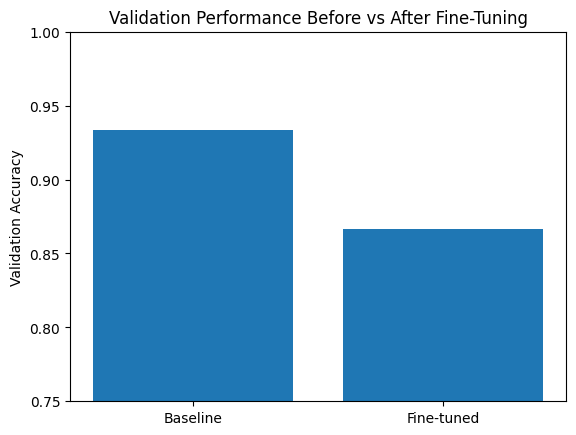

In [17]:
import matplotlib.pyplot as plt

labels = ["Baseline", "Fine-tuned"]
accuracy = [baseline_metrics["accuracy"], finetuned_metrics["accuracy"]]

plt.bar(labels, accuracy)
plt.ylabel("Validation Accuracy")
plt.title("Validation Performance Before vs After Fine-Tuning")
plt.ylim(0.75, 1.0)
plt.show()

The fine tuned model shows a modest drop in in-distribution validation accuracy (93% --> 87%), reflecting a shift in decision boundary to accommodate broader generator diversity.

Taken together, these results illustrate a common real world challenge in applied machine learning: strong validation performance does not guarantee deployment robustness, particularly in rapidly evolving generative ecosystems.

#### Limitations

This reproducible experiment is intentionally lightweight and designed for reproducibility and clarity rather than scale and deployment. Nonetheless, it's important to acknowledge any limitations with this work:

- The dataset is small (150 real, 150 fake, 70 external tracks), which limits statistical power
- Audio duration is cut to 5 seconds, which could rule out any longer range structure
- Genre, recording quality, and different data sources may act as confounding variables
- Fine tuning was performed on a small number of external samples; performance may vary under larger distribution shifts

The original capstone project used substantially more data and a GPU-trained SpecTTTra architecture. This repository focuses on demonstrating the evaluation framework rather than replicating full scale performance.

#### Next Steps

If I were deploying this system, the next steps would focus on
1. Stronger controls for confounding factors (genre, recording quality, mastering)
2. Calibration - so predicted probabilities align with real world risk
3. Monitoring and retraining policies to respond to generator drift over time

The experiments above suggest a practical workflow: ship a baseline model, continuously evaluate on new generator distributions, and fine tune carefully while monitoring impact on false positives.